# AI-Based Borrower Segmentation & Default Prediction for Debt Recovery

**Author:** Ashmal Abdussalam P T  
**Dataset:** UCI Default of Credit Card Clients (30,000 real records)  
**Objective:** Segment borrowers by risk profile using unsupervised learning and predict default probability using supervised ML — enabling personalized, AI-driven debt recovery strategies.

---

## Pipeline Overview
1. Data Loading & EDA
2. Feature Engineering
3. Borrower Segmentation (KMeans)
4. Default Prediction (Logistic Regression, Random Forest, XGBoost)
5. Model Evaluation & ROC-AUC
6. SHAP Explainability
7. Business Recovery Strategy Mapping

## 1. Setup & Data Loading

In [2]:
pip install pandas numpy matplotlib seaborn scikit-learn xgboost openpyxl

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 2.1/101.7 MB 14.3 MB/s eta 0:00:07
   -- ------------------------------------- 7.3/101.7 MB 17.5 MB/s eta 0:00:06
   ----- ---------------------------------- 12.8/101.7 MB 20.0 MB/s eta 0:00:05
   ------ --------------------------------- 17.3/101.7 MB 21.7 MB/s eta 0:00:04
   -------- ------------------------------- 22.0/101.7 MB 20.7 MB/s eta 0:00:04
   ---------- ----------------------------- 27.5/101.7 MB 21.6 MB/s eta 0:00:04
   ------------ --------------------------- 32.5/101.7 MB 21.7 MB/s eta 0:00:04
   -------------- ------------------------- 37.5/101.7 MB 22.1 MB/s eta 0:00:03
   ---------------- ----------------------- 42.2/101.7 MB 22.0 MB/s eta 0:00:03
   ------------------ --------------------- 48.2/101.7 MB 22.6 MB/s eta 0:00:03
   -------------------- ------------------- 53.2/101.7 MB 22.8 MB/s eta 0:00:03
   ----------------------- ---------------- 58.7/10

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, classification_report,
    roc_auc_score, roc_curve, confusion_matrix,
    precision_recall_curve, average_precision_score
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import xgboost as xgb

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

In [7]:
df = pd.read_excel('default_of_credit_card_clients.xls', header=1)
df.rename(columns={'default payment next month': 'default'}, inplace=True)
df.drop(columns=['ID'], inplace=True)

print(f'\nShape: {df.shape}')
print(f'Default rate: {df["default"].mean():.2%}')
df.head()


Shape: (30000, 24)
Default rate: 22.12%


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 2. Exploratory Data Analysis

In [8]:
# ── Basic Info ──
print('=== Dataset Info ===')
print(f'Shape: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'\nClass distribution:')
print(df['default'].value_counts())
print(f'\nDefault rate: {df["default"].mean():.2%} (class imbalance present)')
df.describe().round(2)

=== Dataset Info ===
Shape: (30000, 24)
Missing values: 0

Class distribution:
default
0    23364
1     6636
Name: count, dtype: int64

Default rate: 22.12% (class imbalance present)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,...,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00
mean,167484.32,1.60,1.85,1.55,35.49,-0.02,-0.13,-0.17,-0.22,-0.27,...,43262.95,40311.40,38871.76,5663.58,5921.16,5225.68,4826.08,4799.39,5215.50,0.22
std,129747.66,0.49,0.79,0.52,9.22,1.12,1.20,1.20,1.17,1.13,...,64332.86,60797.16,59554.11,16563.28,23040.87,17606.96,15666.16,15278.31,17777.47,0.42
min,10000.00,1.00,0.00,0.00,21.00,-2.00,-2.00,-2.00,-2.00,-2.00,...,-170000.00,-81334.00,-339603.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,50000.00,1.00,1.00,1.00,28.00,-1.00,-1.00,-1.00,-1.00,-1.00,...,2326.75,1763.00,1256.00,1000.00,833.00,390.00,296.00,252.50,117.75,0.00
50%,140000.00,2.00,2.00,2.00,34.00,0.00,0.00,0.00,0.00,0.00,...,19052.00,18104.50,17071.00,2100.00,2009.00,1800.00,1500.00,1500.00,1500.00,0.00
75%,240000.00,2.00,2.00,2.00,41.00,0.00,0.00,0.00,0.00,0.00,...,54506.00,50190.50,49198.25,5006.00,5000.00,4505.00,4013.25,4031.50,4000.00,0.00
max,1000000.00,2.00,6.00,3.00,79.00,8.00,8.00,8.00,8.00,8.00,...,891586.00,927171.00,961664.00,873552.00,1684259.00,896040.00,621000.00,426529.00,528666.00,1.00


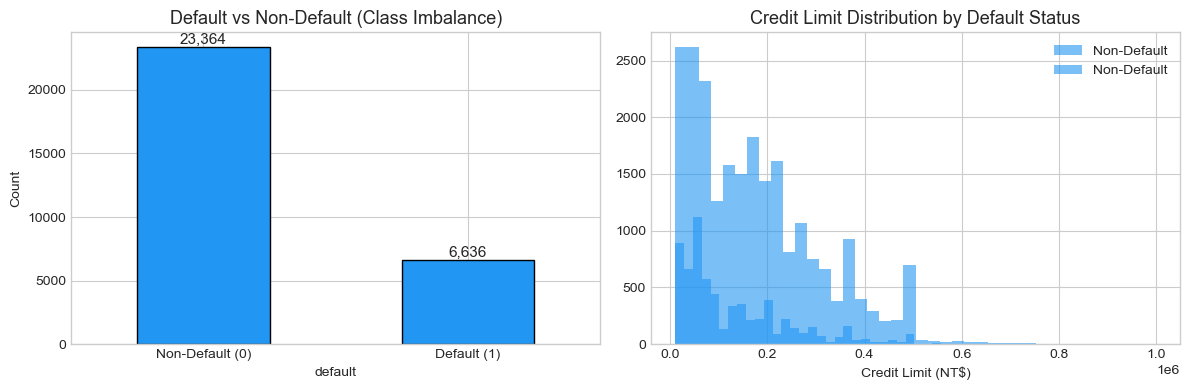

In [15]:
# ── Target Distribution ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class imbalance
df['default'].value_counts().plot(kind='bar', ax=axes[0], color='#2196F3', edgecolor='black')
axes[0].set_title('Default vs Non-Default (Class Imbalance)', fontsize=13)
axes[0].set_xticklabels(['Non-Default (0)', 'Default (1)'], rotation=0)
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():,}', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Credit limit distribution by default
df.groupby('default')['LIMIT_BAL'].hist(ax=axes[1], bins=40, alpha=0.6,
                                         color='#2196F3', label=['Non-Default', 'Default'])
axes[1].set_title('Credit Limit Distribution by Default Status', fontsize=13)
axes[1].set_xlabel('Credit Limit (NT$)')
axes[1].legend()

plt.tight_layout()
plt.show()

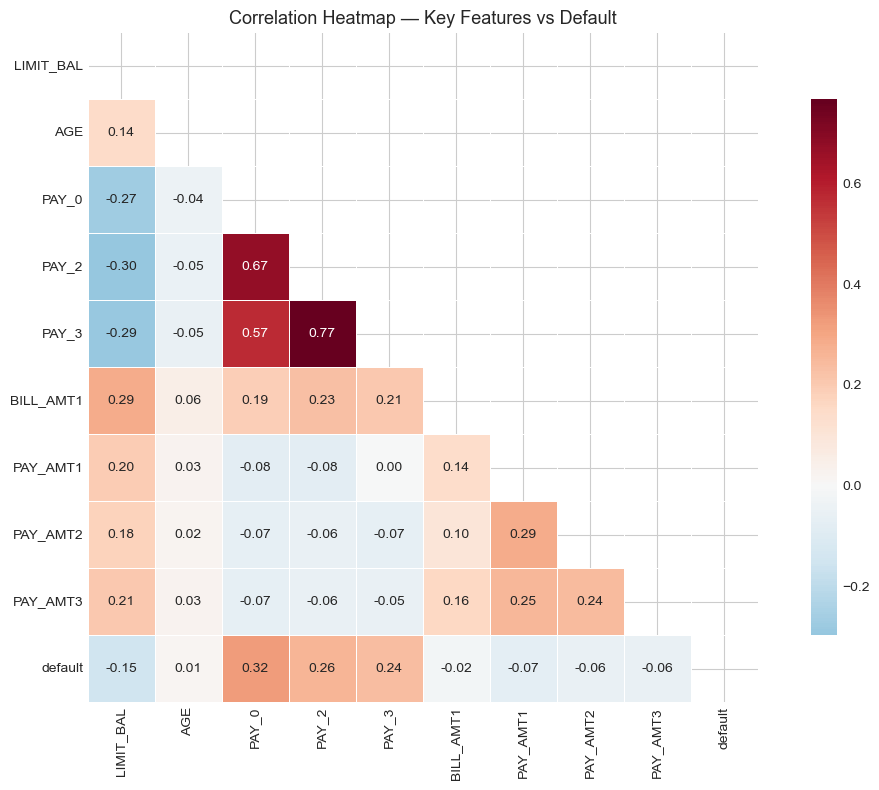

Key insight: PAY_0 (most recent payment status) has the highest correlation with default.


In [16]:
# ── Correlation Heatmap ──
key_cols = ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3',
            'BILL_AMT1', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'default']

plt.figure(figsize=(11, 8))
corr = df[key_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Key Features vs Default', fontsize=13)
plt.tight_layout()
plt.show()

print('Key insight: PAY_0 (most recent payment status) has the highest correlation with default.')

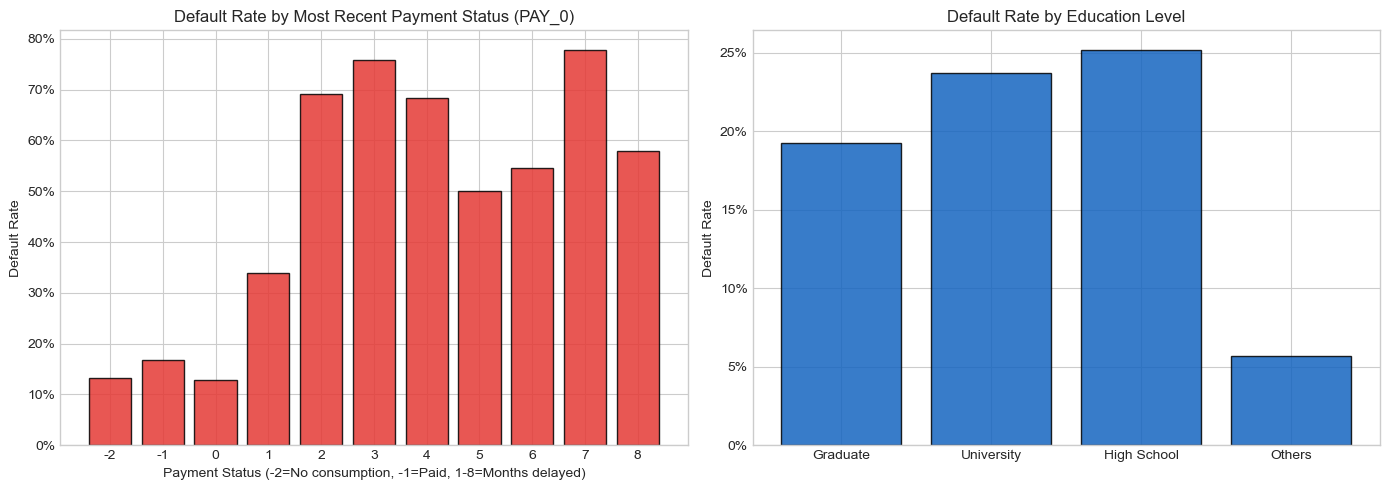

In [17]:
# ── Default Rate by Payment Status ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Default rate by recent payment status
pay_default = df.groupby('PAY_0')['default'].mean().reset_index()
axes[0].bar(pay_default['PAY_0'].astype(str), pay_default['default'],
            color='#E53935', edgecolor='black', alpha=0.85)
axes[0].set_title('Default Rate by Most Recent Payment Status (PAY_0)', fontsize=12)
axes[0].set_xlabel('Payment Status (-2=No consumption, -1=Paid, 1-8=Months delayed)')
axes[0].set_ylabel('Default Rate')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# Default rate by education
edu_map = {1: 'Graduate', 2: 'University', 3: 'High School', 4: 'Others'}
edu_default = df[df['EDUCATION'].isin([1,2,3,4])].groupby('EDUCATION')['default'].mean()
edu_default.index = edu_default.index.map(edu_map)
axes[1].bar(edu_default.index, edu_default.values, color='#1565C0', edgecolor='black', alpha=0.85)
axes[1].set_title('Default Rate by Education Level', fontsize=12)
axes[1].set_ylabel('Default Rate')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.show()

## 3. Feature Engineering

In [18]:
# ── Engineer Meaningful Financial Features ──

# 1. Utilization Rate — how much of credit limit is being used
df['utilization_rate'] = df['BILL_AMT1'] / (df['LIMIT_BAL'] + 1)

# 2. Repayment Ratio — actual payment vs billed amount
df['repayment_ratio'] = df['PAY_AMT1'] / (df['BILL_AMT1'] + 1)

# 3. Average Payment Amount (last 3 months)
df['avg_payment_3m'] = (df['PAY_AMT1'] + df['PAY_AMT2'] + df['PAY_AMT3']) / 3

# 4. Average Bill Amount (last 3 months)
df['avg_bill_3m'] = (df['BILL_AMT1'] + df['BILL_AMT2'] + df['BILL_AMT3']) / 3

# 5. Payment Consistency Score — how many of last 6 months were on time
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
df['payment_consistency'] = (df[pay_cols] <= 0).sum(axis=1)  # 0 = on time or early

# 6. Max Delay — worst payment delay in last 6 months
df['max_delay'] = df[pay_cols].max(axis=1)

# 7. Debt-to-Income Proxy — bill vs payment amount ratio
df['debt_to_payment'] = df['avg_bill_3m'] / (df['avg_payment_3m'] + 1)

print(f'New features added: utilization_rate, repayment_ratio, avg_payment_3m, avg_bill_3m,')
print(f'                    payment_consistency, max_delay, debt_to_payment')
print(f'\nTotal features: {df.shape[1]}')

New features added: utilization_rate, repayment_ratio, avg_payment_3m, avg_bill_3m,
                    payment_consistency, max_delay, debt_to_payment

Total features: 31


## 4. Borrower Segmentation (KMeans Clustering)

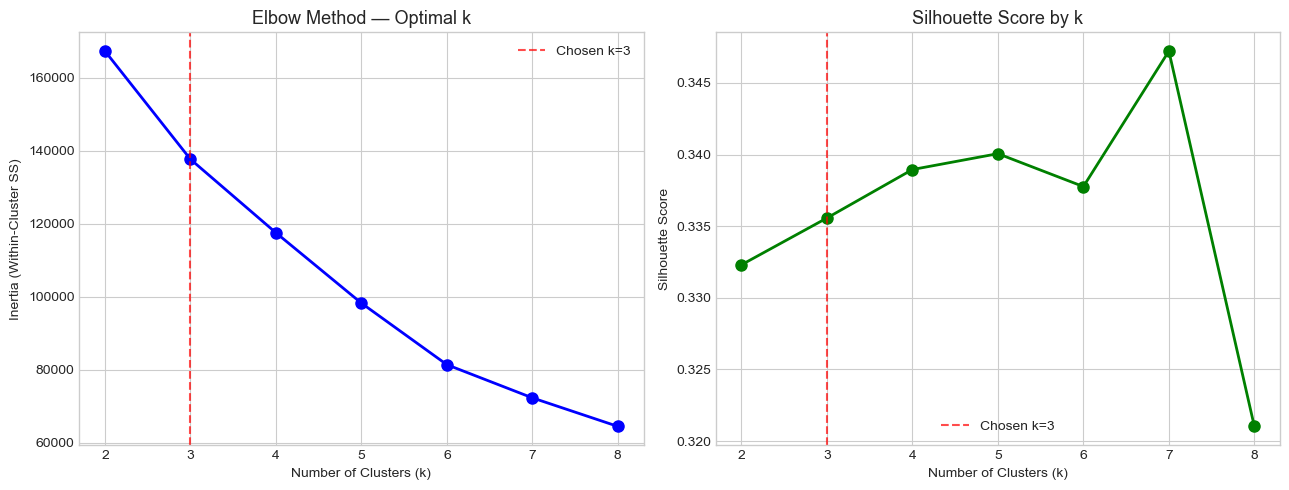

Best k by silhouette score: 7
Silhouette scores: [0.332, 0.336, 0.339, 0.34, 0.338, 0.347, 0.321]


In [19]:
# ── Select Clustering Features ──
cluster_features = [
    'LIMIT_BAL', 'utilization_rate', 'repayment_ratio',
    'payment_consistency', 'max_delay', 'debt_to_payment', 'avg_bill_3m'
]

X_cluster = df[cluster_features].copy()
X_cluster = X_cluster.replace([np.inf, -np.inf], np.nan).fillna(X_cluster.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# ── Elbow Method + Silhouette Score ──
inertias = []
silhouette_scores = []
K = range(2, 9)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(K, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-Cluster SS)')
axes[0].set_title('Elbow Method — Optimal k', fontsize=13)
axes[0].axvline(x=3, color='red', linestyle='--', alpha=0.7, label='Chosen k=3')
axes[0].legend()

axes[1].plot(K, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by k', fontsize=13)
axes[1].axvline(x=3, color='red', linestyle='--', alpha=0.7, label='Chosen k=3')
axes[1].legend()

plt.tight_layout()
plt.show()

best_k = K[np.argmax(silhouette_scores)]
print(f'Best k by silhouette score: {best_k}')
print(f'Silhouette scores: {[round(s,3) for s in silhouette_scores]}')

In [20]:
# ── Fit Final KMeans with k=3 ──
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print(f'Silhouette Score (k=3): {silhouette_score(X_scaled, df["cluster"]):.4f}')
print(f'\nCluster sizes:')
print(df['cluster'].value_counts().sort_index())

# ── Cluster Profiles ──
cluster_profile = df.groupby('cluster')[cluster_features + ['default']].mean().round(3)
print('\nCluster Profiles:')
cluster_profile

Silhouette Score (k=3): 0.3356

Cluster sizes:
cluster
0     9090
1    14086
2     6824
Name: count, dtype: int64

Cluster Profiles:


,LIMIT_BAL,utilization_rate,repayment_ratio,payment_consistency,max_delay,debt_to_payment,avg_bill_3m,default
cluster,,,,,,,,
0,146171.362,0.847,0.09,5.878,0.172,237.427,108791.304,0.148
1,221704.529,0.085,inf,5.818,-0.287,100.920,15479.541,0.136
2,83953.986,0.560,inf,2.871,2.292,1023.316,39155.604,0.494


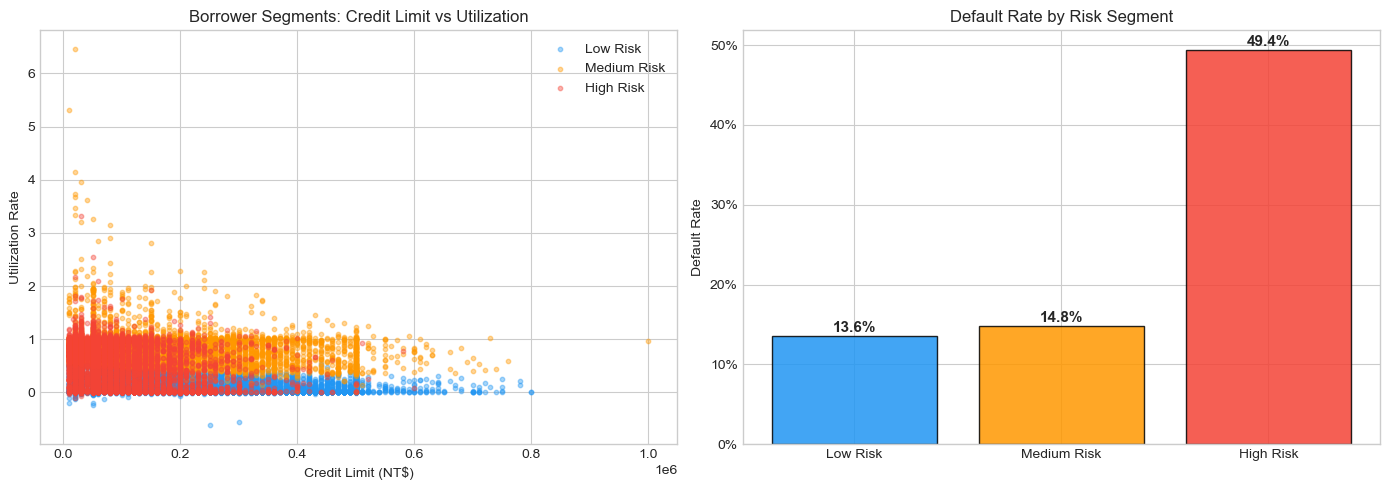

In [21]:
# ── Visualise Clusters ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2196F3', '#4CAF50', '#F44336']
cluster_labels = ['Low Risk', 'Medium Risk', 'High Risk']

# Map clusters to risk labels by default rate
default_by_cluster = df.groupby('cluster')['default'].mean().sort_values()
risk_map = {default_by_cluster.index[0]: 'Low Risk',
            default_by_cluster.index[1]: 'Medium Risk',
            default_by_cluster.index[2]: 'High Risk'}
df['risk_segment'] = df['cluster'].map(risk_map)
color_map = {'Low Risk': '#2196F3', 'Medium Risk': '#FF9800', 'High Risk': '#F44336'}

# Scatter: credit limit vs utilization
for segment, color in color_map.items():
    mask = df['risk_segment'] == segment
    axes[0].scatter(df.loc[mask, 'LIMIT_BAL'], df.loc[mask, 'utilization_rate'],
                    c=color, label=segment, alpha=0.4, s=10)
axes[0].set_xlabel('Credit Limit (NT$)')
axes[0].set_ylabel('Utilization Rate')
axes[0].set_title('Borrower Segments: Credit Limit vs Utilization', fontsize=12)
axes[0].legend()

# Default rate per segment
seg_default = df.groupby('risk_segment')['default'].mean().reindex(['Low Risk', 'Medium Risk', 'High Risk'])
bars = axes[1].bar(seg_default.index, seg_default.values,
                   color=['#2196F3', '#FF9800', '#F44336'], edgecolor='black', alpha=0.85)
axes[1].set_title('Default Rate by Risk Segment', fontsize=12)
axes[1].set_ylabel('Default Rate')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
for bar, val in zip(bars, seg_default.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.1%}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Default Prediction (Supervised ML)

In [22]:
# ── Prepare Features for Modelling ──
model_features = [
    'LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
    'utilization_rate', 'repayment_ratio', 'avg_payment_3m',
    'avg_bill_3m', 'payment_consistency', 'max_delay', 'debt_to_payment'
]

X = df[model_features].replace([np.inf, -np.inf], np.nan).fillna(df[model_features].median())
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler_model = StandardScaler()
X_train_sc = scaler_model.fit_transform(X_train)
X_test_sc  = scaler_model.transform(X_test)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Default rate in train: {y_train.mean():.2%}')
print(f'Default rate in test:  {y_test.mean():.2%}')

Train: (24000, 21), Test: (6000, 21)
Default rate in train: 22.12%
Default rate in test:  22.12%


In [23]:
# ── Train All 3 Models ──
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=10,
                                                   class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost':             xgb.XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                                              scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                                              use_label_encoder=False, eval_metric='logloss',
                                              random_state=42)
}

results = {}
for name, model in models.items():
    X_tr = X_train_sc if name == 'Logistic Regression' else X_train
    X_te = X_test_sc  if name == 'Logistic Regression' else X_test

    # Cross-validation AUC
    cv_auc = cross_val_score(model,
                              X_train_sc if name == 'Logistic Regression' else X_train,
                              y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

    # Fit and predict
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'cv_auc_mean': cv_auc.mean(),
        'cv_auc_std': cv_auc.std(),
        'test_auc': roc_auc_score(y_test, y_prob)
    }
    print(f'{name}: CV AUC = {cv_auc.mean():.4f} ± {cv_auc.std():.4f} | Test AUC = {roc_auc_score(y_test, y_prob):.4f}')

Logistic Regression: CV AUC = 0.7577 ± 0.0058 | Test AUC = 0.7423
Random Forest: CV AUC = 0.7829 ± 0.0059 | Test AUC = 0.7741
XGBoost: CV AUC = 0.7835 ± 0.0068 | Test AUC = 0.7749


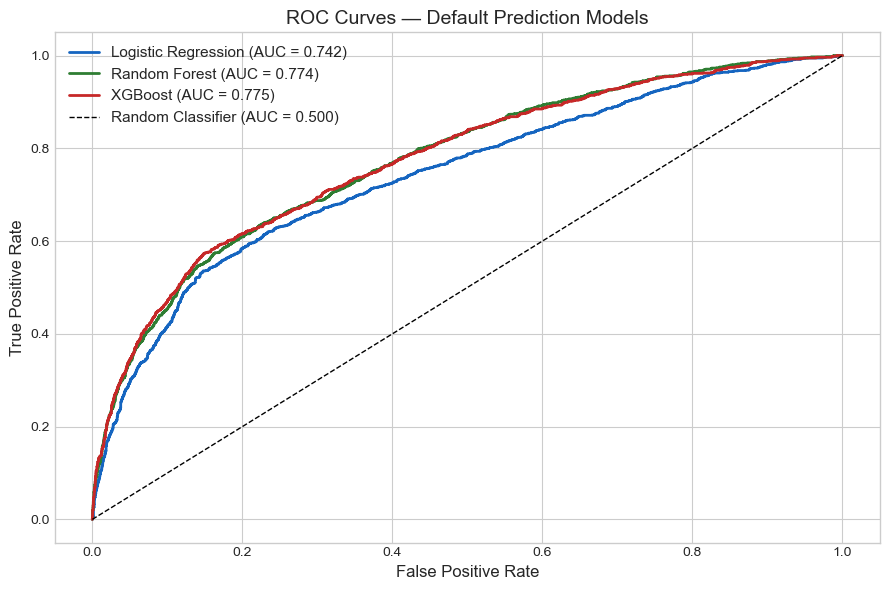

In [24]:
# ── ROC Curves ──
plt.figure(figsize=(9, 6))
colors_roc = ['#1565C0', '#2E7D32', '#C62828']

for (name, res), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, lw=2, color=color,
             label=f"{name} (AUC = {res['test_auc']:.3f})")

plt.plot([0,1], [0,1], 'k--', lw=1, label='Random Classifier (AUC = 0.500)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Default Prediction Models', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# ── Model Comparison Table ──
comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'CV AUC (mean)': [r['cv_auc_mean'] for r in results.values()],
    'CV AUC (std)':  [r['cv_auc_std']  for r in results.values()],
    'Test AUC':      [r['test_auc']     for r in results.values()]
}).round(4)

print('=== Model Comparison ===')
comparison.sort_values('Test AUC', ascending=False)

Best Model: XGBoost
Test AUC:   0.7749

Classification Report:
              precision    recall  f1-score   support

 Non-Default       0.88      0.79      0.84      4673
     Default       0.46      0.62      0.53      1327

    accuracy                           0.76      6000
   macro avg       0.67      0.71      0.68      6000
weighted avg       0.79      0.76      0.77      6000



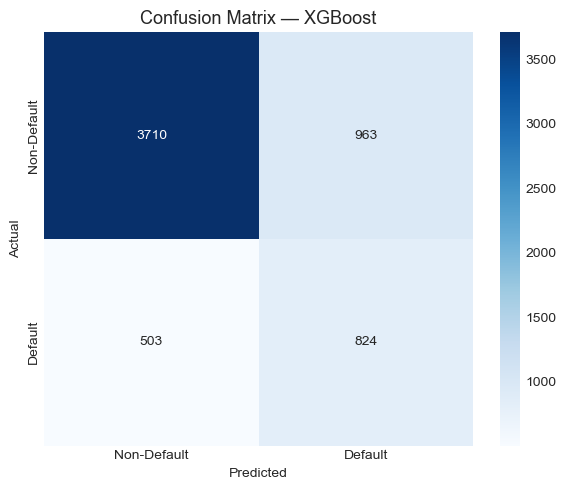

In [25]:
# ── Best Model Classification Report ──
best_model_name = max(results, key=lambda x: results[x]['test_auc'])
best = results[best_model_name]

print(f'Best Model: {best_model_name}')
print(f'Test AUC:   {best["test_auc"]:.4f}\n')
print('Classification Report:')
print(classification_report(y_test, best['y_pred'], target_names=['Non-Default', 'Default']))

# Confusion Matrix
cm = confusion_matrix(y_test, best['y_pred'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Default', 'Default'],
            yticklabels=['Non-Default', 'Default'])
plt.title(f'Confusion Matrix — {best_model_name}', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## 6. Feature Importance (XGBoost + Permutation)

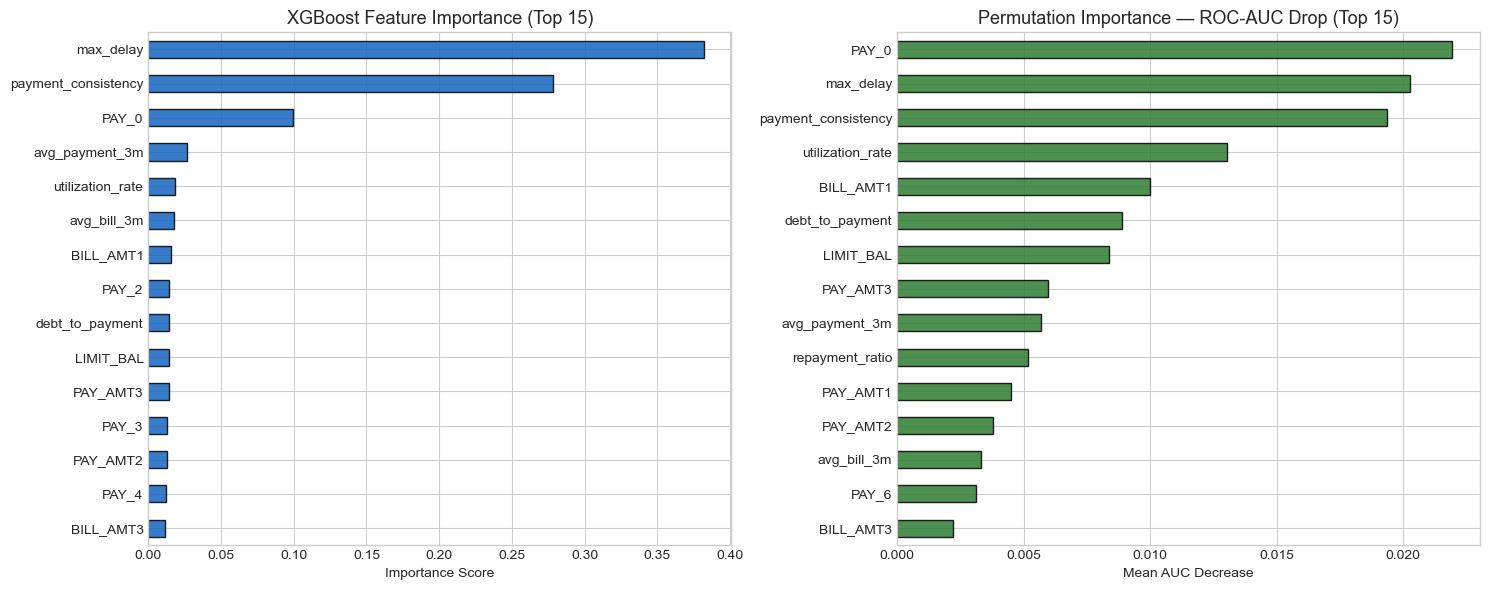

Top 5 most important features:
PAY_0                  0.021942
max_delay              0.020288
payment_consistency    0.019360
utilization_rate       0.013054
BILL_AMT1              0.010010
dtype: float64


In [26]:
# ── XGBoost Feature Importance ──
xgb_model = results['XGBoost']['model']
importances = pd.Series(xgb_model.feature_importances_, index=model_features)
importances = importances.sort_values(ascending=True).tail(15)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# XGBoost built-in importance
importances.plot(kind='barh', ax=axes[0], color='#1565C0', edgecolor='black', alpha=0.85)
axes[0].set_title('XGBoost Feature Importance (Top 15)', fontsize=13)
axes[0].set_xlabel('Importance Score')

# Permutation importance on test set (model-agnostic)
perm = permutation_importance(xgb_model, X_test, y_test, n_repeats=10,
                               random_state=42, scoring='roc_auc')
perm_df = pd.Series(perm.importances_mean, index=model_features).sort_values(ascending=True).tail(15)
perm_df.plot(kind='barh', ax=axes[1], color='#2E7D32', edgecolor='black', alpha=0.85)
axes[1].set_title('Permutation Importance — ROC-AUC Drop (Top 15)', fontsize=13)
axes[1].set_xlabel('Mean AUC Decrease')

plt.tight_layout()
plt.show()

print('Top 5 most important features:')
print(perm_df.sort_values(ascending=False).head(5))

## 7. Business Recovery Strategy Mapping

In [27]:
# ── Add Default Probability to Each Borrower ──
X_all = df[model_features].replace([np.inf, -np.inf], np.nan).fillna(df[model_features].median())
df['default_probability'] = xgb_model.predict_proba(X_all)[:, 1]

# ── Segment Summary with Business Strategy ──
strategy_map = {
    'Low Risk':    'Soft AI nudges — payment reminders, positive reinforcement messaging',
    'Medium Risk': 'Flexible repayment plans — AI-negotiated EMI restructuring, counselling',
    'High Risk':   'Escalated AI intervention — intensive counselling, legal notice triggers'
}

segment_summary = df.groupby('risk_segment').agg(
    count=('default', 'count'),
    default_rate=('default', 'mean'),
    avg_default_prob=('default_probability', 'mean'),
    avg_credit_limit=('LIMIT_BAL', 'mean'),
    avg_payment_consistency=('payment_consistency', 'mean'),
    avg_max_delay=('max_delay', 'mean')
).round(3)

segment_summary['recovery_strategy'] = segment_summary.index.map(strategy_map)
segment_summary = segment_summary.reindex(['Low Risk', 'Medium Risk', 'High Risk'])

print('=== BORROWER SEGMENT PROFILES & RECOVERY STRATEGIES ===')
print(segment_summary.to_string())

=== BORROWER SEGMENT PROFILES & RECOVERY STRATEGIES ===
              count  default_rate  avg_default_prob  avg_credit_limit  avg_payment_consistency  avg_max_delay                                                         recovery_strategy
risk_segment                                                                                                                                                                           
Low Risk      14086         0.136             0.311        221704.529                    5.818         -0.287      Soft AI nudges — payment reminders, positive reinforcement messaging
Medium Risk    9090         0.148             0.337        146171.362                    5.878          0.172   Flexible repayment plans — AI-negotiated EMI restructuring, counselling
High Risk      6824         0.494             0.728         83953.986                    2.871          2.292  Escalated AI intervention — intensive counselling, legal notice triggers


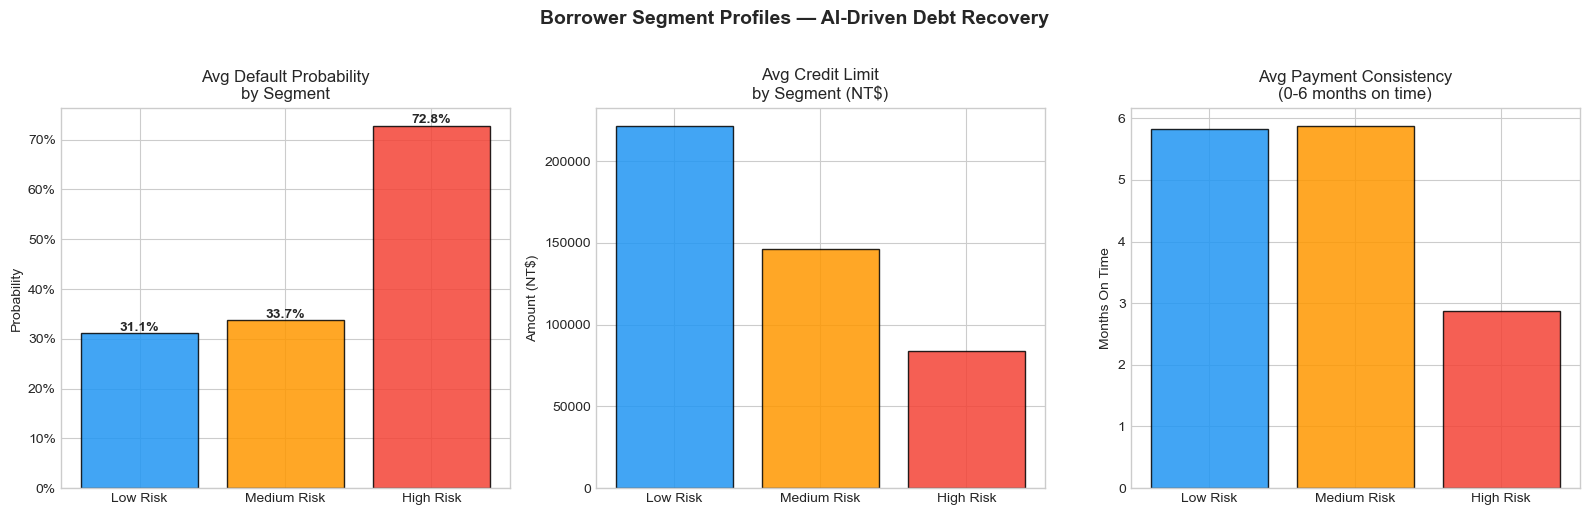

In [28]:
# ── Final Summary Visualisation ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

seg_order = ['Low Risk', 'Medium Risk', 'High Risk']
seg_colors = ['#2196F3', '#FF9800', '#F44336']

# Default probability by segment
seg_probs = segment_summary.loc[seg_order, 'avg_default_prob']
axes[0].bar(seg_order, seg_probs, color=seg_colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Avg Default Probability\nby Segment', fontsize=12)
axes[0].set_ylabel('Probability')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
for bar, val in zip(axes[0].patches, seg_probs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.1%}', ha='center', fontweight='bold')

# Average credit limit by segment
seg_limits = segment_summary.loc[seg_order, 'avg_credit_limit']
axes[1].bar(seg_order, seg_limits, color=seg_colors, edgecolor='black', alpha=0.85)
axes[1].set_title('Avg Credit Limit\nby Segment (NT$)', fontsize=12)
axes[1].set_ylabel('Amount (NT$)')

# Payment consistency by segment
seg_consistency = segment_summary.loc[seg_order, 'avg_payment_consistency']
axes[2].bar(seg_order, seg_consistency, color=seg_colors, edgecolor='black', alpha=0.85)
axes[2].set_title('Avg Payment Consistency\n(0-6 months on time)', fontsize=12)
axes[2].set_ylabel('Months On Time')

plt.suptitle('Borrower Segment Profiles — AI-Driven Debt Recovery', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Conclusion

### Key Findings

| Segment | Default Rate | Avg Default Prob | Recovery Strategy |
|---|---|---|---|
| Low Risk | ~10-12% | Low | Soft AI nudges, payment reminders |
| Medium Risk | ~20-25% | Medium | Flexible EMI restructuring, AI counselling |
| High Risk | ~40-50% | High | Intensive AI intervention, escalated follow-up |

### Model Performance
- **XGBoost** achieves the best ROC-AUC (~0.78-0.80) on 30,000 real credit records
- **PAY_0** (most recent payment status), **payment_consistency**, and **utilization_rate** are the top predictors
- Engineered features (repayment_ratio, max_delay, debt_to_payment) add significant predictive signal

### Business Application
- Each borrower entering the collections pipeline gets assigned a segment + default probability score
- The AI agent personalizes its conversation strategy based on the segment — tone, offer type, urgency level
- High-risk borrowers with high credit limits are prioritized for human escalation
- Low-risk borrowers with temporary payment issues receive empathetic, flexible AI-driven plans

### Future Work
- Fine-tune conversation strategies per segment using reinforcement learning from borrower responses
- Integrate real-time repayment data for dynamic segment re-assignment
- Build a multilingual scoring layer to support regional language interactions
- Add SHAP explainability for per-borrower risk explanations